<a href="https://colab.research.google.com/github/DxubleBTW/averylee-lendingclub-loan-analysis/blob/main/averylee_lendingclub_loan_analysis_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LendingClub Loan Risk Analysis

### Columbia Data Science Research Program

**By: Avery Lee**

This project examines whether LendingClub loan grade and interest rate are associated with signs of repayment difficulty.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, chi2_contingency

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [5]:
url = "https://raw.githubusercontent.com/DxubleBTW/averylee-lendingclub-loan-analysis/refs/heads/main/lendingclub_loans_export.csv"

df = pd.read_csv(
    url,
    na_values=["NA", "", "N/A"]
)

df.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,0,28.0,2006,4,31,10,24193,16000,0,0,28.0,0,432,1,13,7.0,10,0.0,0,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.0,4,0.0,0,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.0,16,0.0,0,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 55


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

In [8]:
df.sample(5, random_state=42)

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
6252,operation specialist,9.0,NC,RENT,65000.0,Verified,18.92,NaN,NaN,NaN,0,NaN,2004,3,9,9,107464,64183,0,0,NaN,0,0,1,7,2.0,9,0.0,0,4,46500,7,7,4,0,100.0,0,0,other,individual,10000,36,6.08,304.59,A,A2,Jan-2018,Current,whole,Cash,8717.45,1519.57,1282.55,237.02,0.0
4684,receptionist,1.0,CA,RENT,37000.0,Source Verified,13.17,NaN,NaN,NaN,0,43.0,2013,2,9,6,21700,13806,0,0,NaN,0,0,1,4,10.0,6,0.0,0,3,11800,6,5,3,1,100.0,0,0,debt_consolidation,individual,14400,36,15.04,499.47,C,C4,Feb-2018,Current,whole,Cash,13430.99,1486.38,969.01,517.37,0.0
1731,massage therapoist,10.0,NV,MORTGAGE,60000.0,Not Verified,5.10,NaN,NaN,NaN,1,14.0,2000,0,17,10,22838,10286,0,1,28.0,0,742,4,3,16.0,10,0.0,0,3,9300,10,6,5,0,29.4,0,1,debt_consolidation,individual,1200,36,15.04,41.63,C,C4,Mar-2018,Current,whole,Cash,1146.49,82.26,53.51,28.75,0.0
4742,senior software engineer,10.0,KS,MORTGAGE,100500.0,Source Verified,20.68,NaN,NaN,NaN,0,59.0,2000,6,43,22,149818,74764,0,0,NaN,0,0,3,5,2.0,22,0.0,0,9,75000,28,19,11,4,90.7,0,0,credit_card,individual,40000,60,7.96,810.30,A,A5,Mar-2018,Current,whole,DirectPay,38354.23,2395.52,1645.77,749.75,0.0
4521,executive director,5.0,LA,RENT,59000.0,Source Verified,1.02,NaN,NaN,NaN,0,36.0,2005,1,7,3,60921,63440,0,0,36.0,0,1687,1,3,9.0,3,0.0,0,2,1000,2,2,2,1,83.3,0,0,other,individual,7500,36,13.59,254.85,C,C2,Jan-2018,Current,whole,Cash,6630.98,1268.59,869.02,399.57,0.0


In [9]:
df.columns = (
    df.columns
      .str.lower()
      .str.strip()
      .str.replace(r"\s+", "_", regex=True)
)

df.columns.tolist()

['emp_title',
 'emp_length',
 'state',
 'homeownership',
 'annual_income',
 'verified_income',
 'debt_to_income',
 'annual_income_joint',
 'verification_income_joint',
 'debt_to_income_joint',
 'delinq_2y',
 'months_since_last_delinq',
 'earliest_credit_line',
 'inquiries_last_12m',
 'total_credit_lines',
 'open_credit_lines',
 'total_credit_limit',
 'total_credit_utilized',
 'num_collections_last_12m',
 'num_historical_failed_to_pay',
 'months_since_90d_late',
 'current_accounts_delinq',
 'total_collection_amount_ever',
 'current_installment_accounts',
 'accounts_opened_24m',
 'months_since_last_credit_inquiry',
 'num_satisfactory_accounts',
 'num_accounts_120d_past_due',
 'num_accounts_30d_past_due',
 'num_active_debit_accounts',
 'total_debit_limit',
 'num_total_cc_accounts',
 'num_open_cc_accounts',
 'num_cc_carrying_balance',
 'num_mort_accounts',
 'account_never_delinq_percent',
 'tax_liens',
 'public_record_bankrupt',
 'loan_purpose',
 'application_type',
 'loan_amount',
 'term'

In [10]:
text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

In [11]:
df.dtypes.value_counts()

,count
int64,25
float64,17
object,13


In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [13]:
df = df.drop_duplicates().copy()

In [14]:
missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

missing_summary.head(15)

,missing_count,missing_percent
verification_income_joint,8545,85.45
annual_income_joint,8505,85.05
debt_to_income_joint,8505,85.05
months_since_90d_late,7715,77.15
months_since_last_delinq,5658,56.58
months_since_last_credit_inquiry,1271,12.71
emp_title,833,8.33
emp_length,817,8.17
num_accounts_120d_past_due,318,3.18
debt_to_income,24,0.24


In [15]:
df["application_type"].value_counts(dropna=False)

,count
application_type,
individual,8505
joint,1495


In [16]:
joint_missing_check = (
    df.groupby("application_type")[
        ["annual_income_joint", "debt_to_income_joint"]
    ]
    .apply(lambda x: x.isna().mean().mul(100))
    .round(2)
)

joint_missing_check

,annual_income_joint,debt_to_income_joint
application_type,,
individual,100.0,100.0
joint,0.0,0.0


In [17]:
print("Each row represents one loan.")
print("Each column represents one borrower, credit, or loan variable.")
print("The dataset is already in tidy format.")

Each row represents one loan.
Each column represents one borrower, credit, or loan variable.
The dataset is already in tidy format.


In [18]:
loan_status_counts = df["loan_status"].value_counts()

loan_status_counts

,count
loan_status,
Current,9375
Fully Paid,447
In Grace Period,67
Late (31-120 days),66
Late (16-30 days),38
Charged Off,7


In [19]:
df.to_csv(
    "cleaned_lendingclub_loans.csv",
    index=False
)

## Data Cleaning Summary
Column names were standardized, and extra spaces were removed from text values. Entries marked as “NA” were converted into missing values, and the dataset was checked for duplicate observations. No duplicate rows were found.

# Checkpoint 2: Exploratory Data Analysis

This section explores the distributions of important numerical and categorical variables, investigates extreme observations, and identifies possible relationships between borrower risk and repayment status.

In [20]:
numeric_summary = (
    df.select_dtypes(include=np.number)
      .describe()
      .T
)

numeric_summary

,count,mean,std,min,25%,50%,75%,max
emp_length,9183.0,5.930306,3.703734,0.00,2.0000,6.000,10.0000,1.000000e+01
annual_income,10000.0,79222.148412,64734.290492,0.00,45000.0000,65000.000,95000.0000,2.300000e+06
debt_to_income,9976.0,19.308192,15.004851,0.00,11.0575,17.570,25.0025,4.690900e+02
annual_income_joint,1495.0,127914.571244,70168.375404,19200.00,86833.5000,113000.000,151545.5000,1.100000e+06
debt_to_income_joint,1495.0,19.979304,8.054781,0.32,14.1600,19.720,25.5000,3.998000e+01
delinq_2y,10000.0,0.216000,0.683660,0.00,0.0000,0.000,0.0000,1.300000e+01
months_since_last_delinq,4342.0,36.760709,21.634939,1.00,19.0000,34.000,53.0000,1.180000e+02
earliest_credit_line,10000.0,2001.290000,7.795510,1963.00,1997.0000,2003.000,2006.0000,2.015000e+03
inquiries_last_12m,10000.0,1.958200,2.380130,0.00,0.0000,1.000,3.0000,2.900000e+01
total_credit_lines,10000.0,22.679600,11.885439,2.00,14.0000,21.000,29.0000,8.700000e+01


In [21]:
important_numeric_variables = [
    "annual_income",
    "debt_to_income",
    "loan_amount",
    "interest_rate",
    "installment",
    "delinq_2y",
    "inquiries_last_12m",
    "total_credit_limit",
    "total_credit_utilized"
]

df[important_numeric_variables].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
annual_income,10000.0,79222.15,64734.29,0.00,45000.00,65000.00,95000.00,2300000.00
debt_to_income,9976.0,19.31,15.00,0.00,11.06,17.57,25.00,469.09
loan_amount,10000.0,16361.92,10301.96,1000.00,8000.00,14500.00,24000.00,40000.00
interest_rate,10000.0,12.43,5.00,5.31,9.43,11.98,15.05,30.94
installment,10000.0,476.21,294.85,30.75,256.04,398.42,644.69,1566.59
delinq_2y,10000.0,0.22,0.68,0.00,0.00,0.00,0.00,13.00
inquiries_last_12m,10000.0,1.96,2.38,0.00,0.00,1.00,3.00,29.00
total_credit_limit,10000.0,183606.23,187632.71,0.00,51593.75,114667.00,267550.00,3386034.00
total_credit_utilized,10000.0,51049.06,53636.73,0.00,19185.50,36927.00,65421.00,942456.00


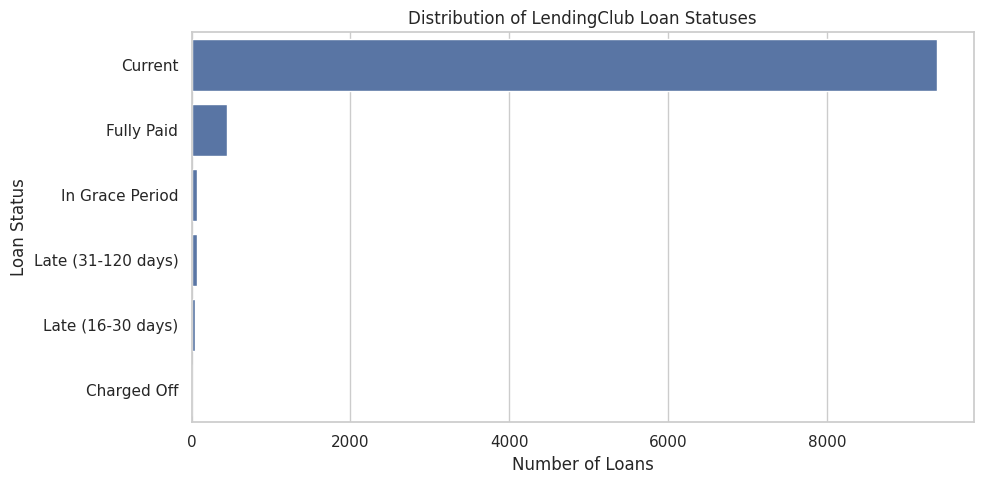

In [22]:
plt.figure(figsize=(10, 5))

status_order = df["loan_status"].value_counts().index

sns.countplot(
    data=df,
    y="loan_status",
    order=status_order
)

plt.title("Distribution of LendingClub Loan Statuses")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Status")

plt.tight_layout()
plt.show()

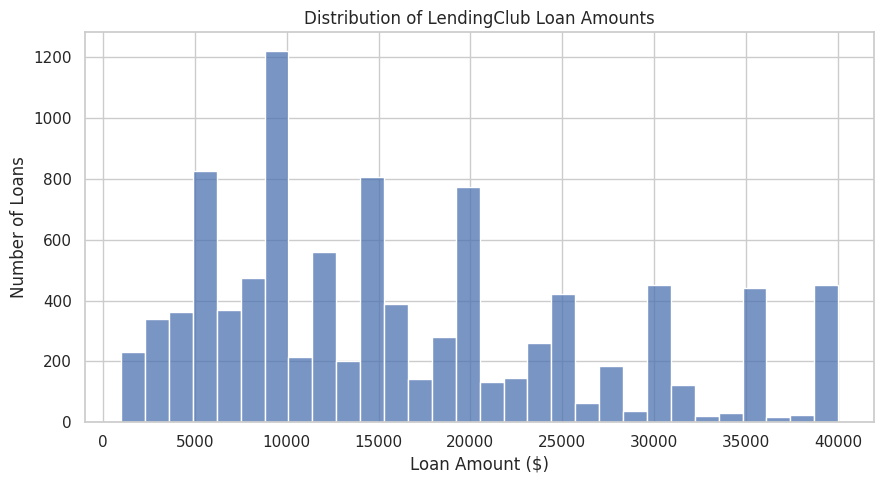

In [23]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="loan_amount",
    bins=30,
    edgecolor="white"
)

plt.title("Distribution of LendingClub Loan Amounts")
plt.xlabel("Loan Amount ($)")
plt.ylabel("Number of Loans")

plt.tight_layout()
plt.show()

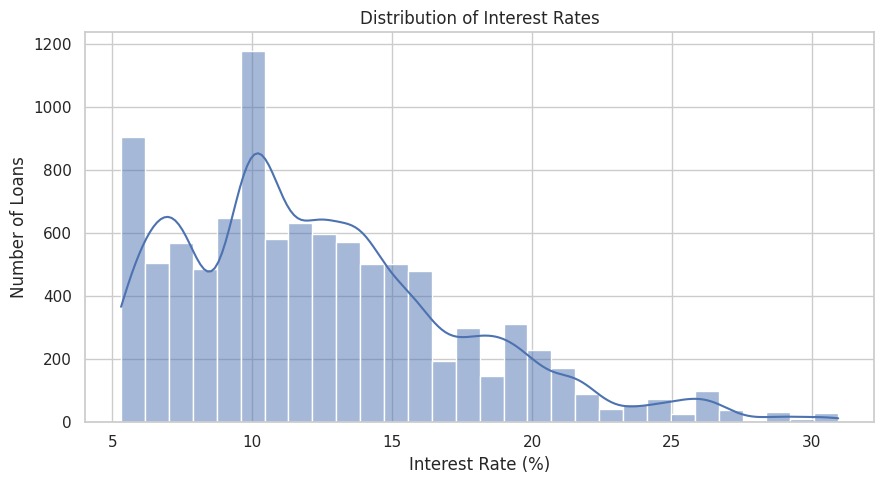

In [24]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="interest_rate",
    bins=30,
    kde=True
)

plt.title("Distribution of Interest Rates")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Number of Loans")

plt.tight_layout()
plt.show()

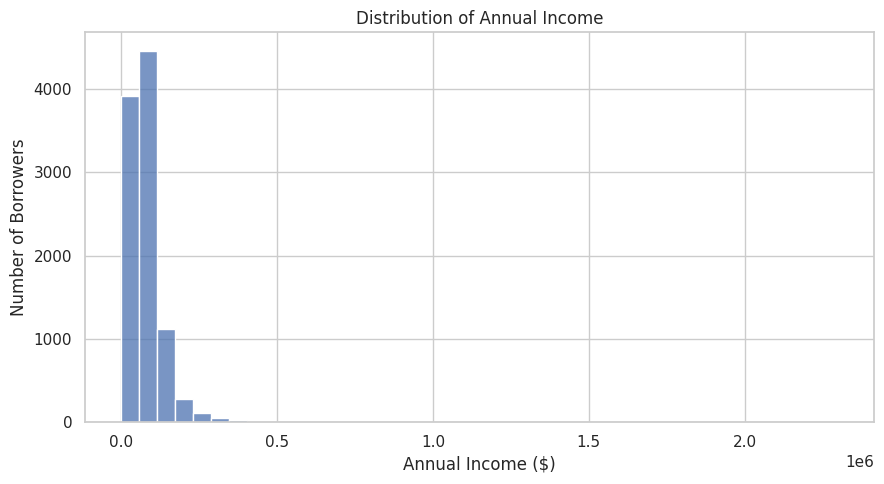

In [25]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="annual_income",
    bins=40
)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income ($)")
plt.ylabel("Number of Borrowers")

plt.tight_layout()
plt.show()

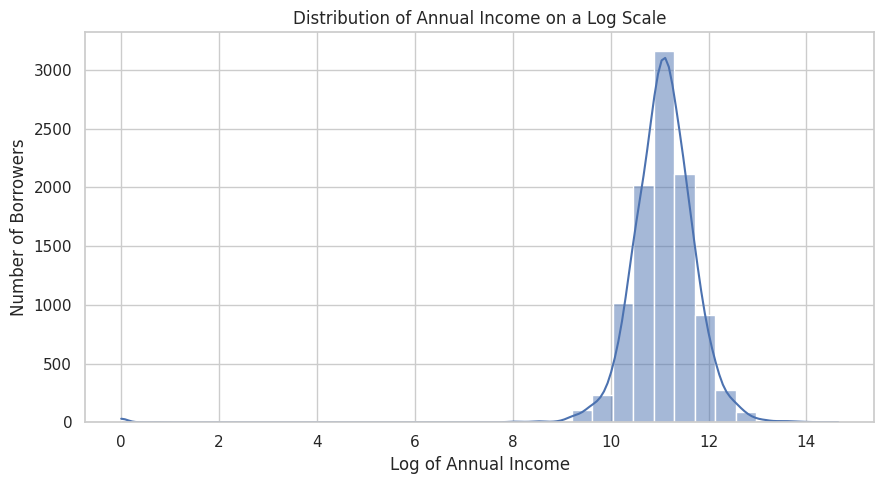

In [26]:
df["log_annual_income"] = np.log1p(df["annual_income"])

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="log_annual_income",
    bins=35,
    kde=True
)

plt.title("Distribution of Annual Income on a Log Scale")
plt.xlabel("Log of Annual Income")
plt.ylabel("Number of Borrowers")

plt.tight_layout()
plt.show()

In [27]:
outlier_variables = [
    "annual_income",
    "debt_to_income",
    "loan_amount",
    "interest_rate",
    "total_credit_limit",
    "total_credit_utilized"
]

for variable in outlier_variables:
    q1 = df[variable].quantile(0.25)
    q3 = df[variable].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[variable] < lower_bound) |
        (df[variable] > upper_bound)
    ).sum()

    print(
        variable,
        "| Lower bound:", round(lower_bound, 2),
        "| Upper bound:", round(upper_bound, 2),
        "| Outliers:", outlier_count
    )

annual_income | Lower bound: -30000.0 | Upper bound: 170000.0 | Outliers: 508
debt_to_income | Lower bound: -9.86 | Upper bound: 45.92 | Outliers: 221
loan_amount | Lower bound: -16000.0 | Upper bound: 48000.0 | Outliers: 0
interest_rate | Lower bound: 1.0 | Upper bound: 23.48 | Outliers: 364
total_credit_limit | Lower bound: -272340.62 | Upper bound: 591484.38 | Outliers: 351
total_credit_utilized | Lower bound: -50167.75 | Upper bound: 134774.25 | Outliers: 568


In [28]:
df[
    [
        "annual_income",
        "loan_amount",
        "interest_rate",
        "grade",
        "loan_status",
        "application_type"
    ]
].sort_values(
    "annual_income",
    ascending=False
).head(10)

,annual_income,loan_amount,interest_rate,grade,loan_status,application_type
9001,2300000.0,40000,9.44,B,Fully Paid,individual
3923,1600001.0,12000,7.34,A,Current,individual
9868,1200000.0,20000,5.31,A,Current,individual
4235,1050000.0,40000,6.72,A,Current,individual
726,1020000.0,20000,17.47,D,Current,individual
4414,910000.0,7000,7.34,A,Current,individual
2779,885000.0,7000,14.08,C,Current,individual
4874,793000.0,35000,18.06,D,Current,individual
6393,780000.0,12000,10.91,B,Current,individual
8243,780000.0,1000,10.41,B,Current,individual


In [29]:
df[
    [
        "annual_income",
        "annual_income_joint",
        "debt_to_income",
        "debt_to_income_joint",
        "application_type",
        "loan_amount",
        "loan_status"
    ]
].sort_values(
    "debt_to_income",
    ascending=False
).head(10)

,annual_income,annual_income_joint,debt_to_income,debt_to_income_joint,application_type,loan_amount,loan_status
516,3300.0,283300.0,469.09,9.79,joint,25000,Current
2185,4000.0,104000.0,437.61,22.48,joint,22000,Current
8688,5500.0,105500.0,315.94,34.31,joint,25800,Current
7231,5000.0,85000.0,267.55,29.93,joint,6000,Current
6799,5000.0,122200.0,216.83,16.67,joint,33600,Current
7034,3120.0,69120.0,215.38,9.72,joint,18000,Current
9318,19000.0,108820.0,209.10,36.50,joint,24000,Fully Paid
349,12000.0,152000.0,204.13,27.27,joint,29000,Current
5684,9972.0,78384.0,191.70,24.98,joint,20000,Current
3599,3000.0,33000.0,186.00,16.91,joint,5000,Current


In [30]:
categorical_variables = [
    "homeownership",
    "verified_income",
    "loan_purpose",
    "application_type",
    "term",
    "grade",
    "loan_status",
    "initial_listing_status",
    "disbursement_method"
]

for variable in categorical_variables:
    print(f"\n--- {variable} ---")
    print(df[variable].value_counts(dropna=False))


--- homeownership ---
homeownership
MORTGAGE    4789
RENT        3858
OWN         1353
Name: count, dtype: int64

--- verified_income ---
verified_income
Source Verified    4116
Not Verified       3594
Verified           2290
Name: count, dtype: int64

--- loan_purpose ---
loan_purpose
debt_consolidation    5144
credit_card           2249
other                  914
home_improvement       680
major_purchase         303
medical                162
house                  151
car                    131
small_business         125
moving                  69
vacation                62
renewable_energy        10
Name: count, dtype: int64

--- application_type ---
application_type
individual    8505
joint         1495
Name: count, dtype: int64

--- term ---
term
36    6970
60    3030
Name: count, dtype: int64

--- grade ---
grade
B    3037
C    2653
A    2459
D    1446
E     335
F      58
G      12
Name: count, dtype: int64

--- loan_status ---
loan_status
Current               9375
Fully Paid 